In [1]:
# Install the core simulator, dataset libraries, and the Colab display utility
!pip install transformers==4.41.2
!pip install --upgrade ai2thor prior ai2thor_colab
!pip install -q --upgrade einops timm ultralytics

# !pip install -q --upgrade ai2thor ai2thor_colab prior
# Install the vision models required by the Perception Agent
#!pip install --upgrade ultralytics transformers

In [6]:
!pip install flash_attn

  Using cached flash_attn-2.8.3.tar.gz (8.4 MB)
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [15]:
import os
import shutil
import torch
import prior
from ai2thor.controller import Controller
from PIL import Image
from ultralytics import SAM
from transformers import AutoProcessor, AutoModelForCausalLM
from IPython.display import display, clear_output
import time
import ai2thor_colab

# Import the patching tools needed for the fix
from unittest.mock import patch
from transformers.dynamic_module_utils import get_imports

def workaround_fixed_get_imports(filename: str | os.PathLike) -> list[str]:
    """Intercepts the dependency check and removes flash_attn."""
    if not str(filename).endswith("modeling_florence2.py"):
        return get_imports(filename)

    imports = get_imports(filename)
    if "flash_attn" in imports:
        imports.remove("flash_attn")
    return imports


class FlorencePerceptionAgent:
    def __init__(self, florence_model="microsoft/Florence-2-base", sam_weights="sam2_b.pt", save_dir="saved_agent_data", headless = True):
        if headless:
            ai2thor_colab.start_xserver()
        self.save_dir = save_dir
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        print(f"[PerceptionAgent] Initializing with device: {self.device}")

        # 1. Load Florence-2 (The Open-Vocabulary Detector)
        print("Loading Florence-2... (This may take a moment)")
        self.processor = AutoProcessor.from_pretrained(florence_model, trust_remote_code=True)

        # --- THE FIX ---
        # We wrap the model loading step in the patch context manager.
        # This forces the loader to use our modified dependency list.
        with patch("transformers.dynamic_module_utils.get_imports", workaround_fixed_get_imports):
            self.florence = AutoModelForCausalLM.from_pretrained(
                florence_model,
                trust_remote_code=True,
                attn_implementation="sdpa" # Fall back to standard PyTorch attention
            ).to(self.device)

       # self.florence = AutoModelForCausalLM.from_pretrained(florence_model, trust_remote_code=True).to(self.device)

        # 2. Load SAM2 (The Segmenter)
        print("Loading SAM2...")
        self.sam = SAM(sam_weights)
        self.sam.to(self.device)

        # 3. Dynamic Class Dictionary for Dataset Labeling
        self.class_map = {}
        self.next_class_id = 0

        # Clean workspace
        if os.path.exists(self.save_dir):
            shutil.rmtree(self.save_dir)
        os.makedirs(self.save_dir, exist_ok=True)

    def _get_class_id(self, text_label: str) -> int:
        """Dynamically assigns an integer ID to new object strings discovered by Florence."""
        clean_label = text_label.lower().strip()
        if clean_label not in self.class_map:
            self.class_map[clean_label] = self.next_class_id
            self.next_class_id += 1

            # Save/Update the global class dictionary for the dataset
            dict_path = os.path.join(self.save_dir, "classes.txt")
            with open(dict_path, "w") as f:
                for name, cid in self.class_map.items():
                    f.write(f"{cid}: {name}\n")

        return self.class_map[clean_label]

    def _get_spatial_descriptor(self, normalized_polygon) -> str:
        """Translates normalized polygon points into spatial text."""
        x_coords = [pt[0] for pt in normalized_polygon]
        y_coords = [pt[1] for pt in normalized_polygon]

        center_x = sum(x_coords) / len(x_coords)
        center_y = sum(y_coords) / len(y_coords)

        horizontal = "center"
        if center_x < 0.33: horizontal = "left"
        elif center_x > 0.66: horizontal = "right"

        vertical = "center"
        if center_y < 0.33: vertical = "top"
        elif center_y > 0.66: vertical = "bottom"

        if horizontal == "center" and vertical == "center":
            return "in the center"
        return f"in the {vertical}-{horizontal}"

    def perceive(self, image: Image.Image, frame_name: str) -> str:
        step_dir = os.path.join(self.save_dir, frame_name)
        os.makedirs(step_dir, exist_ok=True)

        # Save raw image
        img_path = os.path.join(step_dir, "frame.jpg")
        image.save(img_path)
        label_file = os.path.join(step_dir, "frame.txt")

        # --- STEP 1: Florence-2 Open Vocabulary Detection ---
        # --- STEP 1: Florence-2 Open Vocabulary Detection ---
        prompt = "<OD>" # Switched to standard Object Detection
        inputs = self.processor(text=prompt, images=image, return_tensors="pt").to(self.device)

        with torch.no_grad():
            generated_ids = self.florence.generate(
                input_ids=inputs["input_ids"],
                pixel_values=inputs["pixel_values"],
                max_new_tokens=1024,
                num_beams=3
            )

        generated_text = self.processor.batch_decode(generated_ids, skip_special_tokens=False)[0]
        parsed_answer = self.processor.post_process_generation(generated_text, task=prompt, image_size=(image.width, image.height))

        # Print exactly what Florence sees to the console so we aren't flying blind
        print(f"\n[DEBUG] Florence Output: {parsed_answer}")

        detections = parsed_answer.get(prompt, {})

        # --- THE FIX ---
        # Check if Florence returned a proper dictionary.
        # If it panicked and returned a string, default to empty lists.
        if isinstance(detections, dict):
            bboxes = detections.get('bboxes', [])
            labels = detections.get('labels', [])
        else:
            bboxes = []
            labels = []
        # Handle Empty Detections
        if len(bboxes) == 0:
            open(label_file, 'w').close()
            return "No distinct objects are visible in the current view."

        # --- STEP 2: SAM2 Segmentation from Florence Boxes ---
        # We pass the Florence bounding boxes directly to SAM as prompts
        sam_results = self.sam(image, bboxes=bboxes, verbose=False)[0]

        description_lines = ["Visible Objects (Segmented):"]

        # Open file to write dataset labels
        with open(label_file, "w") as f:
            # Check if masks were successfully generated
            if sam_results.masks is not None:
                # Iterate through every object detected
                for i, (bbox, label) in enumerate(zip(bboxes, labels)):
                    # Get normalized polygon coordinates from SAM2
                    polygon = sam_results.masks.xyn[i]

                    if len(polygon) < 3:
                        continue # Skip invalid masks

                    # 1. Write to dataset txt file
                    class_id = self._get_class_id(label)
                    flat_coords = " ".join([f"{pt[0]:.5f} {pt[1]:.5f}" for pt in polygon])
                    f.write(f"{class_id} {flat_coords}\n")

                    # 2. Build Text Description for LLM
                    spatial_loc = self._get_spatial_descriptor(polygon)

                    # Calculate Area
                    width = max([p[0] for p in polygon]) - min([p[0] for p in polygon])
                    height = max([p[1] for p in polygon]) - min([p[1] for p in polygon])
                    area_ratio = width * height

                    description_lines.append(f"- {label} located {spatial_loc}, covering roughly {area_ratio:.1%} of the view.")

        if self.device == "cuda":
            torch.cuda.empty_cache()

        return "\n".join(description_lines)

In [16]:
# Run this in its own cell and let it finish completely
from ai2thor.controller import Controller
import prior

dataset = prior.load_dataset("procthor-10k")
house = dataset["train"][0]
agent = FlorencePerceptionAgent(headless=True)

controller = Controller(scene=house)

# Initialize the new Florence-powered Agent


[AI2-THOR WARNING] There has been an update to ProcTHOR-10K that must be used with AI2-THOR version 5.0+. To use the new version of ProcTHOR-10K, please update AI2-THOR to version 5.0+ by running:
    pip install --upgrade ai2thor
Alternatively, to downgrade to the old version of ProcTHOR-10K, run:
   prior.load_dataset("procthor-10k", revision="ab3cacd0fc17754d4c080a3fd50b18395fae8647")


Loading test: 100%|██████████| 1000/1000 [00:00<00:00, 4117.23it/s]


[PerceptionAgent] Initializing with device: cpu
Loading Florence-2... (This may take a moment)
Loading SAM2...



[DEBUG] Florence Output: {'<OD>': {'bboxes': [[20.55000114440918, 59.250003814697266, 65.25, 88.05000305175781]], 'labels': ['window']}}
  Agent Step 1/10 (Turned 0° total)  
Data saved to: /saved_agent_data/step_0/


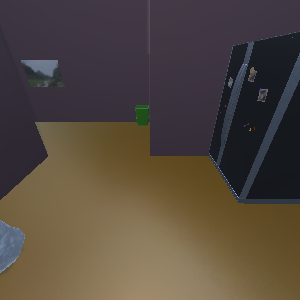


Visible Objects (Segmented):
- window located in the top-left, covering roughly 1.3% of the view.

[DEBUG] Florence Output: {'<OD>': {'bboxes': [[171.15000915527344, 34.35000228881836, 299.5500183105469, 189.15000915527344]], 'labels': ['refrigerator']}}
  Agent Step 2/10 (Turned 15° total)  
Data saved to: /saved_agent_data/step_1/


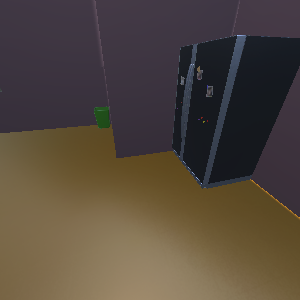


Visible Objects (Segmented):
- refrigerator located in the center-right, covering roughly 21.4% of the view.

[DEBUG] Florence Output: {'<OD>': {'bboxes': [[131.5500030517578, 36.75, 240.45001220703125, 182.25]], 'labels': ['refrigerator']}}
  Agent Step 3/10 (Turned 30° total)  
Data saved to: /saved_agent_data/step_2/


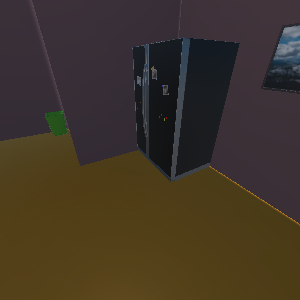


Visible Objects (Segmented):
- refrigerator located in the center, covering roughly 16.6% of the view.

[DEBUG] Florence Output: {'<OD>': {'bboxes': [[208.0500030517578, 19.950000762939453, 299.5500183105469, 94.95000457763672]], 'labels': ['television']}}
  Agent Step 4/10 (Turned 45° total)  
Data saved to: /saved_agent_data/step_3/


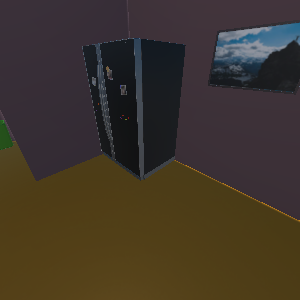


Visible Objects (Segmented):
- television located in the top-right, covering roughly 7.0% of the view.

[DEBUG] Florence Output: {'<OD>': {'bboxes': [[163.0500030517578, 24.750001907348633, 250.65000915527344, 89.85000610351562]], 'labels': ['television']}}
  Agent Step 5/10 (Turned 60° total)  
Data saved to: /saved_agent_data/step_4/


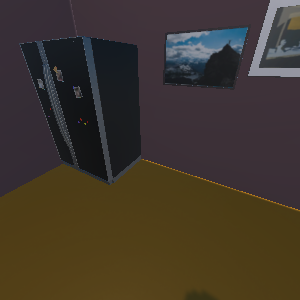


Visible Objects (Segmented):
- television located in the top-right, covering roughly 5.5% of the view.

[DEBUG] Florence Output: {'<OD>': {'bboxes': [[276.75, 187.0500030517578, 299.5500183105469, 213.45001220703125], [273.45001220703125, 166.35000610351562, 299.5500183105469, 213.75001525878906], [196.0500030517578, 0.15000000596046448, 299.5500183105469, 76.35000610351562], [115.6500015258789, 28.950000762939453, 193.35000610351562, 87.45000457763672]], 'labels': ['flowerpot', 'houseplant', 'picture frame', 'television']}}
  Agent Step 6/10 (Turned 75° total)  
Data saved to: /saved_agent_data/step_5/


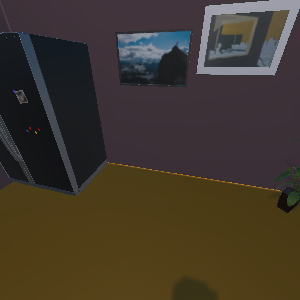


Visible Objects (Segmented):
- flowerpot located in the bottom-right, covering roughly 0.6% of the view.
- houseplant located in the center-right, covering roughly 1.1% of the view.
- picture frame located in the top-right, covering roughly 8.4% of the view.
- television located in the top-center, covering roughly 4.4% of the view.

[DEBUG] Florence Output: {'<OD>': {'bboxes': [[231.45001220703125, 167.5500030517578, 251.85000610351562, 190.0500030517578], [225.15000915527344, 125.25000762939453, 291.45001220703125, 190.65000915527344], [150.15000915527344, 7.350000381469727, 230.5500030517578, 74.55000305175781], [59.55000305175781, 28.650001525878906, 144.45001220703125, 87.45000457763672]], 'labels': ['flowerpot', 'houseplant', 'picture frame', 'picture frame']}}
  Agent Step 7/10 (Turned 90° total)  
Data saved to: /saved_agent_data/step_6/


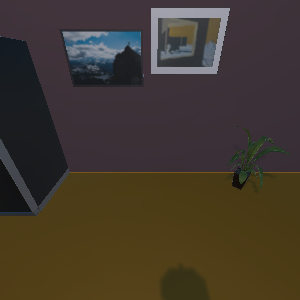


Visible Objects (Segmented):
- flowerpot located in the center-right, covering roughly 0.4% of the view.
- houseplant located in the center-right, covering roughly 3.9% of the view.
- picture frame located in the top-right, covering roughly 5.6% of the view.
- picture frame located in the top-center, covering roughly 4.9% of the view.

[DEBUG] Florence Output: {'<OD>': {'bboxes': [[187.35000610351562, 119.85000610351562, 236.85000610351562, 177.45001220703125], [0.15000000596046448, 23.25, 100.35000610351562, 91.6500015258789], [97.95000457763672, 5.850000381469727, 174.15000915527344, 74.85000610351562], [265.6500244140625, 61.35000228881836, 299.5500183105469, 89.85000610351562]], 'labels': ['houseplant', 'picture frame', 'picture frame', 'picture frame']}}
  Agent Step 8/10 (Turned 105° total)  
Data saved to: /saved_agent_data/step_7/


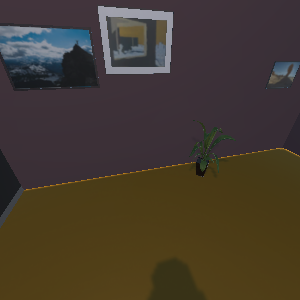


Visible Objects (Segmented):
- houseplant located in the center-right, covering roughly 2.6% of the view.
- picture frame located in the top-left, covering roughly 6.9% of the view.
- picture frame located in the top-center, covering roughly 5.5% of the view.
- picture frame located in the top-right, covering roughly 1.0% of the view.

[DEBUG] Florence Output: {'<OD>': {'bboxes': [[152.25, 117.75000762939453, 194.25001525878906, 171.45001220703125], [33.150001525878906, 0.15000000596046448, 125.85000610351562, 75.75], [0.15000000596046448, 19.950000762939453, 49.05000305175781, 94.05000305175781], [211.0500030517578, 61.05000305175781, 235.35000610351562, 85.95000457763672]], 'labels': ['houseplant', 'picture frame', 'picture frame', 'picture frame']}}
  Agent Step 9/10 (Turned 120° total)  
Data saved to: /saved_agent_data/step_8/


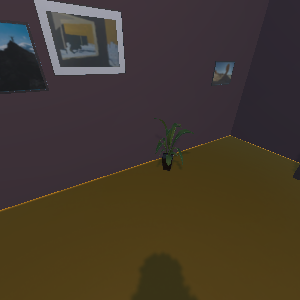


Visible Objects (Segmented):
- houseplant located in the center, covering roughly 2.0% of the view.
- picture frame located in the top-left, covering roughly 7.4% of the view.
- picture frame located in the top-left, covering roughly 3.8% of the view.
- picture frame located in the top-right, covering roughly 0.6% of the view.

[DEBUG] Florence Output: {'<OD>': {'bboxes': [[128.5500030517578, 152.85000610351562, 140.85000610351562, 170.25], [118.05000305175781, 118.95000457763672, 157.0500030517578, 170.25]], 'labels': ['flowerpot', 'houseplant']}}
  Agent Step 10/10 (Turned 135° total)  
Data saved to: /saved_agent_data/step_9/


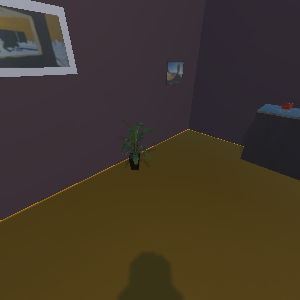


Visible Objects (Segmented):
- flowerpot located in the center, covering roughly 0.2% of the view.
- houseplant located in the center, covering roughly 1.7% of the view.

[Sequence Complete. Check 'saved_agent_data/classes.txt' for the dynamic label dictionary.]


In [17]:




total_steps = 10
degrees_per_step = 15

for step in range(total_steps):
    if step > 0:
        event = controller.step(action="RotateRight", degrees=degrees_per_step)
    else:
        event = controller.last_event

    current_frame = Image.fromarray(event.frame)
    step_id = f"step_{step}"

    # Run pipeline
    scene_description = agent.perceive(current_frame, frame_name=step_id)

    # Render Output
    #clear_output(wait=True)
    print(f"======================================")
    print(f"  Agent Step {step + 1}/{total_steps} (Turned {step * degrees_per_step}° total)  ")
    print(f"======================================")
    print(f"Data saved to: /saved_agent_data/{step_id}/")

    display(current_frame)
    print("\n" + scene_description)
    time.sleep(0.5)

print("\n[Sequence Complete. Check 'saved_agent_data/classes.txt' for the dynamic label dictionary.]")